In [1]:
import os
import copy
import time
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, DataLoader
import torchvision
from torchvision import datasets, transforms, models

SEED = 42
BATCH_SIZE = 128
NUM_WORKERS = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

Using device: cuda


## Part 1 - Data Preparation
Load CIFAR-10, create train/validation split, and build numpy arrays for classical models.


In [2]:
# CIFAR-10 classes
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
NUM_CLASSES = len(CLASS_NAMES)

# Base dataset without augmentation for indexing and classical ML
base_transform = transforms.ToTensor()

train_full_base = datasets.CIFAR10(
    root="./data", train=True, download=True, transform=base_transform
)
test_base = datasets.CIFAR10(
    root="./data", train=False, download=True, transform=base_transform
)

train_targets = np.array(train_full_base.targets)

train_idx, val_idx = train_test_split(
    np.arange(len(train_targets)),
    test_size=0.2,
    stratify=train_targets,
    random_state=SEED
)

print(f"Train samples: {len(train_idx)}")
print(f"Validation samples: {len(val_idx)}")
print(f"Test samples: {len(test_base)}")

Train samples: 40000
Validation samples: 10000
Test samples: 10000


In [3]:
def dataset_to_numpy(dataset):
    X = []
    y = []
    for img, label in tqdm(dataset):
        # img is torch tensor [C,H,W] in [0,1]
        X.append(img.numpy().reshape(-1))
        y.append(label)
    X = np.array(X)
    y = np.array(y)
    return X, y

# Use subsets from the same original training set
train_subset_base = Subset(train_full_base, train_idx)
val_subset_base = Subset(train_full_base, val_idx)

X_train_full, y_train_full = dataset_to_numpy(train_subset_base)
X_val_full, y_val = dataset_to_numpy(val_subset_base)
X_test_full, y_test = dataset_to_numpy(test_base)

print(X_train_full.shape, y_train_full.shape)
print(X_val_full.shape, y_val.shape)
print(X_test_full.shape, y_test.shape)

  0%|          | 0/40000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

(40000, 3072) (40000,)
(10000, 3072) (10000,)
(10000, 3072) (10000,)


In [4]:
# Adjust these if you want faster or more complete runs
CLASSICAL_TRAIN_SAMPLES = 15000
CLASSICAL_VAL_SAMPLES = 4000
CLASSICAL_TEST_SAMPLES = 5000

def stratified_subsample(X, y, n_samples, seed=SEED):
    if n_samples >= len(y):
        return X, y
    idx = np.arange(len(y))
    chosen_idx, _ = train_test_split(
        idx,
        train_size=n_samples,
        stratify=y,
        random_state=seed
    )
    return X[chosen_idx], y[chosen_idx]

X_train, y_train = stratified_subsample(X_train_full, y_train_full, CLASSICAL_TRAIN_SAMPLES)
X_val, y_val_small = stratified_subsample(X_val_full, y_val, CLASSICAL_VAL_SAMPLES)
X_test, y_test_small = stratified_subsample(X_test_full, y_test, CLASSICAL_TEST_SAMPLES)

print("Classical ML subset shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val_small.shape)
print("Test: ", X_test.shape, y_test_small.shape)

Classical ML subset shapes:
Train: (15000, 3072) (15000,)
Val:   (4000, 3072) (4000,)
Test:  (5000, 3072) (5000,)


## Part 2 - Classical Baselines
Train classical classifiers and track accuracy, precision, recall, and F1 (weighted).


In [5]:
classical_models = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=200, random_state=SEED)),
        ("clf", LogisticRegression(max_iter=2000, random_state=SEED, n_jobs=-1))
    ]),
    
    "LinearSVM": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=200, random_state=SEED)),
        ("clf", LinearSVC(random_state=SEED, max_iter=5000))
    ]),
    
    "RandomForest": Pipeline([
        ("pca", PCA(n_components=200, random_state=SEED)),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            random_state=SEED,
            n_jobs=-1
        ))
    ]),
    
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=100, random_state=SEED)),
        ("clf", KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
    ]),
}

In [6]:
classical_results = {}
classical_predictions = {}
classical_conf_mats = {}

def compute_cls_metrics(y_true, y_pred, average="weighted"):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average=average, zero_division=0
    )
    return {
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

for name, model in classical_models.items():
    print(f"{name}: training")
    start = time.time()

    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    val_acc = accuracy_score(y_val_small, val_pred)
    test_acc = accuracy_score(y_test_small, test_pred)
    val_metrics = compute_cls_metrics(y_val_small, val_pred)
    test_metrics = compute_cls_metrics(y_test_small, test_pred)

    classical_results[name] = {
        "model_type": "Classical ML",
        "val_acc": val_acc,
        "test_acc": test_acc,
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
        "test_f1": test_metrics["f1"],
        "train_time_sec": time.time() - start
    }
    classical_predictions[name] = test_pred
    classical_conf_mats[name] = confusion_matrix(y_test_small, test_pred)

    print(
        f"{name} | val_f1={val_metrics['f1']:.4f} | test_f1={test_metrics['f1']:.4f} "
        f"| test_precision={test_metrics['precision']:.4f} | test_recall={test_metrics['recall']:.4f}"
    )


LogisticRegression: training
LogisticRegression | val_f1=0.3993 | test_f1=0.3951 | test_precision=0.3936 | test_recall=0.3986
LinearSVM: training
LinearSVM | val_f1=0.3871 | test_f1=0.3808 | test_precision=0.3811 | test_recall=0.3942
RandomForest: training
RandomForest | val_f1=0.4450 | test_f1=0.4317 | test_precision=0.4304 | test_recall=0.4398
KNN: training
KNN | val_f1=0.3289 | test_f1=0.3285 | test_precision=0.4001 | test_recall=0.3402


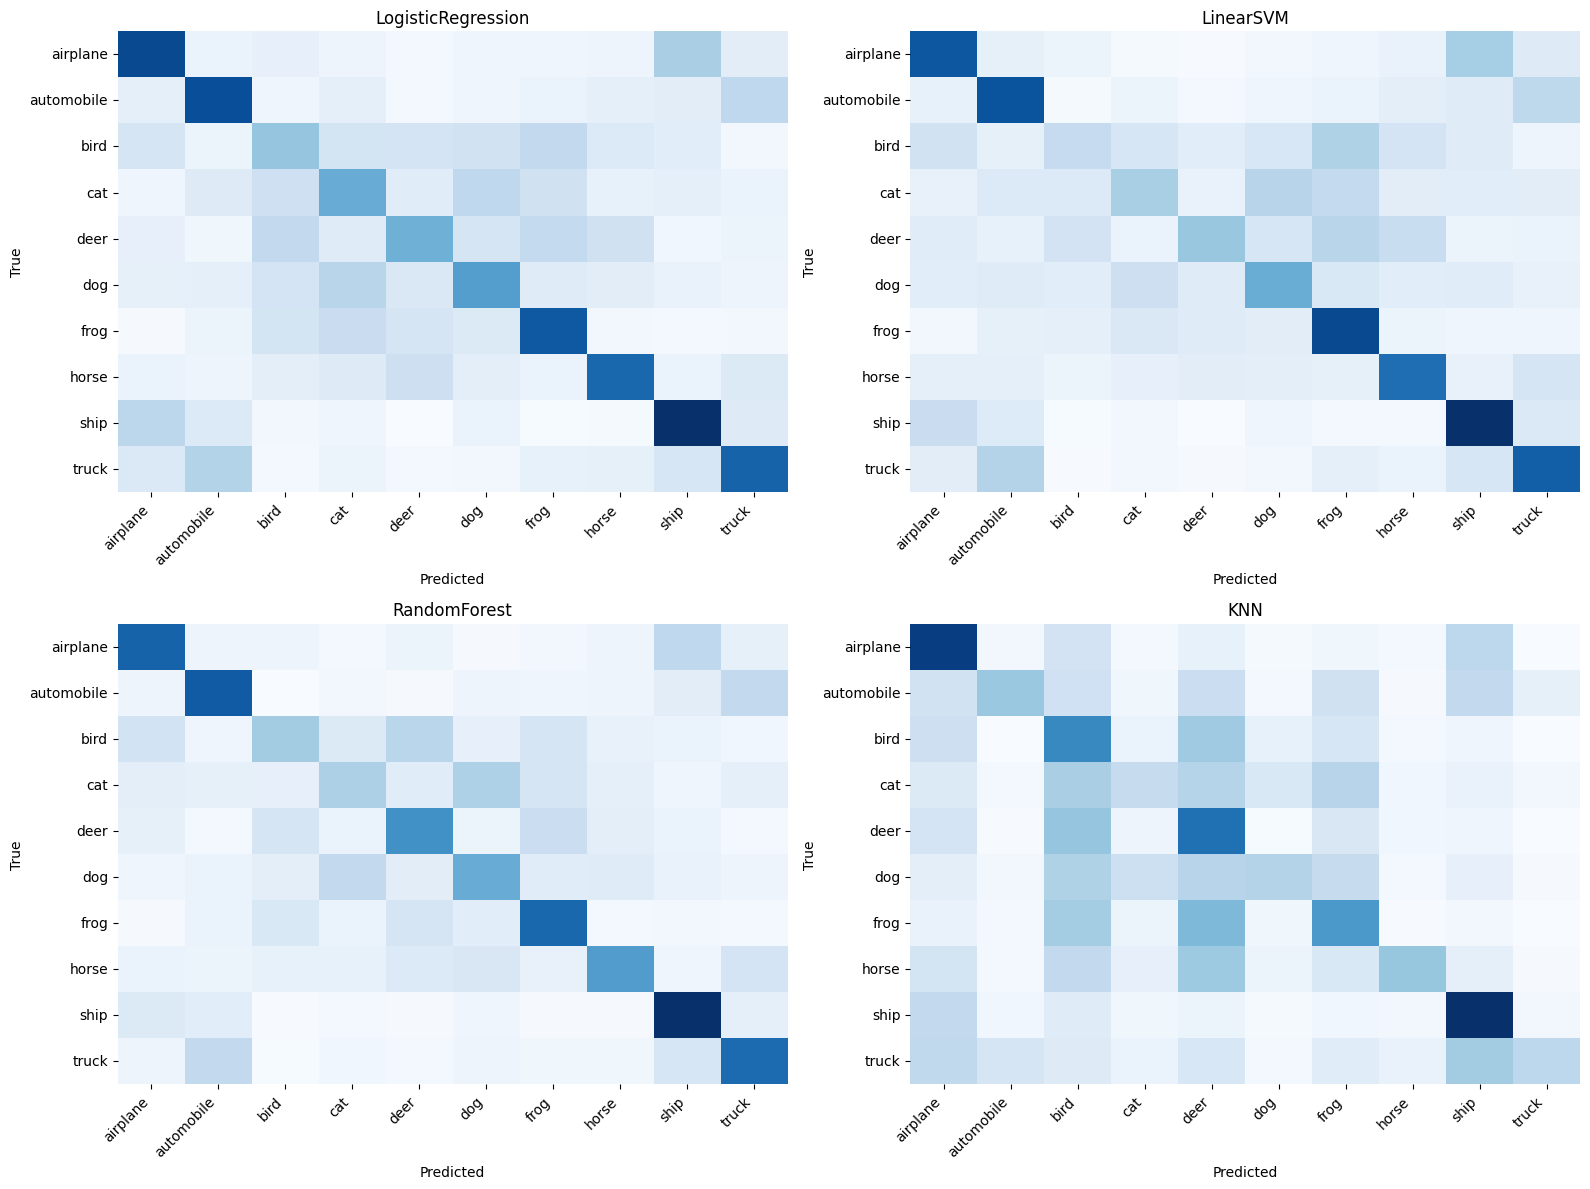

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for ax, (name, cm) in zip(axes, classical_conf_mats.items()):
    sns.heatmap(cm, annot=False, cmap="Blues", cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(np.arange(NUM_CLASSES) + 0.5)
    ax.set_yticks(np.arange(NUM_CLASSES) + 0.5)
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_NAMES, rotation=0)

plt.tight_layout()
plt.show()

## Part 3 - Deep Learning Setup
Define image transforms, loaders, model architectures, and training/evaluation utilities.


In [8]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

eval_transform_32 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

# For pretrained torchvision models like ResNet/EfficientNet/ViT
eval_transform_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225))
])

train_transform_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=16),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225))
])

In [9]:
# Datasets for 32x32 CNN
train_full_32 = datasets.CIFAR10(root="./data", train=True, download=False, transform=train_transform)
val_full_32   = datasets.CIFAR10(root="./data", train=True, download=False, transform=eval_transform_32)
test_32       = datasets.CIFAR10(root="./data", train=False, download=False, transform=eval_transform_32)

train_ds_32 = Subset(train_full_32, train_idx)
val_ds_32   = Subset(val_full_32, val_idx)

train_loader_32 = DataLoader(train_ds_32, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader_32   = DataLoader(val_ds_32, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader_32  = DataLoader(test_32, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Datasets for 224x224 pretrained models
train_full_224 = datasets.CIFAR10(root="./data", train=True, download=False, transform=train_transform_224)
val_full_224   = datasets.CIFAR10(root="./data", train=True, download=False, transform=eval_transform_224)
test_224       = datasets.CIFAR10(root="./data", train=False, download=False, transform=eval_transform_224)

train_ds_224 = Subset(train_full_224, train_idx)
val_ds_224   = Subset(val_full_224, val_idx)

train_loader_224 = DataLoader(train_ds_224, batch_size=64, shuffle=True, num_workers=NUM_WORKERS)
val_loader_224   = DataLoader(val_ds_224, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)
test_loader_224  = DataLoader(test_224, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)

In [10]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [11]:
def compute_cls_metrics(y_true, y_pred, average="weighted"):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average=average, zero_division=0
    )
    return precision, recall, f1

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    preds_all, labels_all = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(y.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(labels_all, preds_all)
    _, _, epoch_f1 = compute_cls_metrics(labels_all, preds_all)
    return epoch_loss, epoch_acc, epoch_f1


@torch.no_grad()
def evaluate_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds_all, labels_all = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(y.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(labels_all, preds_all)
    _, _, epoch_f1 = compute_cls_metrics(labels_all, preds_all)
    return epoch_loss, epoch_acc, epoch_f1, np.array(labels_all), np.array(preds_all)


def fit_model(model, train_loader, val_loader, epochs=8, lr=1e-3, weight_decay=1e-4, device=DEVICE):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "train_loss": [], "train_acc": [], "train_f1": [],
        "val_loss": [], "val_acc": [], "val_f1": []
    }

    best_state = None
    best_val_f1 = -1

    for epoch in range(epochs):
        train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, val_f1, _, _ = evaluate_model(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch+1:02d}/{epochs} - "
            f"train: loss={train_loss:.4f}, acc={train_acc:.4f}, f1={train_f1:.4f} | "
            f"val: loss={val_loss:.4f}, acc={val_acc:.4f}, f1={val_f1:.4f}"
        )

    model.load_state_dict(best_state)
    return model, history


@torch.no_grad()
def test_model(model, loader, device=DEVICE):
    criterion = nn.CrossEntropyLoss()
    loss, acc, f1, y_true, y_pred = evaluate_model(model, loader, criterion, device)
    precision, recall, f1, = compute_cls_metrics(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    return loss, acc, f1, precision, recall, y_true, y_pred, cm


def plot_training_history(history, title="Training History"):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(epochs, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], label="Val Loss")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Train Acc")
    axes[1].plot(epochs, history["val_acc"], label="Val Acc")
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    axes[2].plot(epochs, history["train_f1"], label="Train F1")
    axes[2].plot(epochs, history["val_f1"], label="Val F1")
    axes[2].set_title(f"{title} - F1")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("F1")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


In [12]:
def build_resnet18(num_classes=10):
    weights = models.ResNet18_Weights.DEFAULT
    model = models.resnet18(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

def build_efficientnet_b0(num_classes=10):
    weights = models.EfficientNet_B0_Weights.DEFAULT
    model = models.efficientnet_b0(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

def build_vit_b_16(num_classes=10):
    weights = models.ViT_B_16_Weights.DEFAULT
    model = models.vit_b_16(weights=weights)
    in_features = model.heads.head.in_features
    model.heads.head = nn.Linear(in_features, num_classes)
    return model

## Part 4 - Deep Model Training
Train CNN-based models and evaluate with precision, recall, and F1 (weighted).


SimpleCNN: training
Epoch 01/10 - train: loss=1.5438, acc=0.4308, f1=0.4260 | val: loss=1.1996, acc=0.5671, f1=0.5591
Epoch 02/10 - train: loss=1.1813, acc=0.5769, f1=0.5734 | val: loss=1.0012, acc=0.6366, f1=0.6326
Epoch 03/10 - train: loss=1.0512, acc=0.6284, f1=0.6258 | val: loss=0.9330, acc=0.6656, f1=0.6631
Epoch 04/10 - train: loss=0.9771, acc=0.6555, f1=0.6532 | val: loss=0.9032, acc=0.6812, f1=0.6803
Epoch 05/10 - train: loss=0.9237, acc=0.6753, f1=0.6737 | val: loss=0.8073, acc=0.7163, f1=0.7130
Epoch 06/10 - train: loss=0.8726, acc=0.6906, f1=0.6892 | val: loss=0.8400, acc=0.7067, f1=0.7052
Epoch 07/10 - train: loss=0.8445, acc=0.7054, f1=0.7041 | val: loss=0.7267, acc=0.7445, f1=0.7432
Epoch 08/10 - train: loss=0.8203, acc=0.7108, f1=0.7097 | val: loss=0.7605, acc=0.7273, f1=0.7225
Epoch 09/10 - train: loss=0.7892, acc=0.7245, f1=0.7234 | val: loss=0.6963, acc=0.7545, f1=0.7537
Epoch 10/10 - train: loss=0.7643, acc=0.7342, f1=0.7333 | val: loss=0.7962, acc=0.7285, f1=0.7258


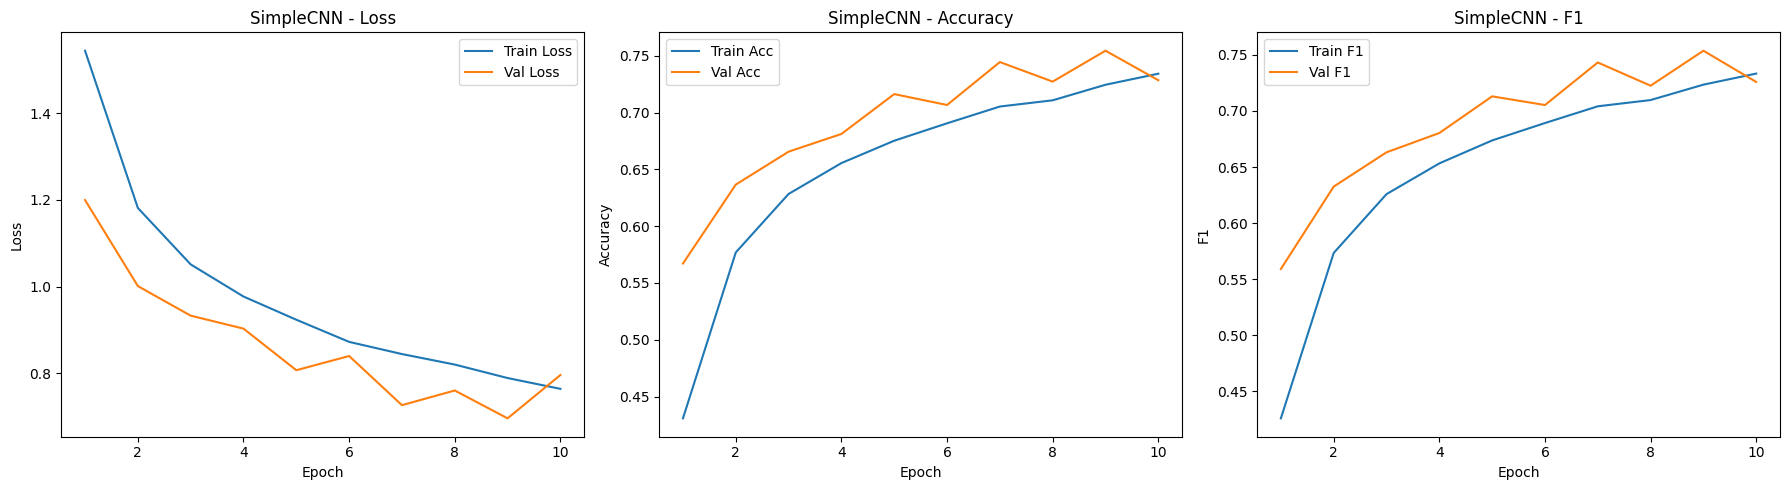

SimpleCNN | test_f1=0.7530 | test_precision=0.7565 | test_recall=0.7540 | test_acc=0.7540


In [13]:
deep_results = {}
deep_histories = {}
deep_conf_mats = {}

print("SimpleCNN: training")
simple_cnn = SimpleCNN(num_classes=NUM_CLASSES)
simple_cnn, hist = fit_model(
    simple_cnn,
    train_loader_32,
    val_loader_32,
    epochs=10,
    lr=1e-3
)
plot_training_history(hist, title="SimpleCNN")

_, val_acc, val_f1, val_precision, val_recall, _, _, _ = test_model(simple_cnn, val_loader_32)
_, test_acc, test_f1, test_precision, test_recall, y_true, y_pred, cm = test_model(simple_cnn, test_loader_32)

deep_results["SimpleCNN"] = {
    "model_type": "Deep Learning",
    "val_acc": val_acc,
    "test_acc": test_acc,
    "val_precision": val_precision,
    "val_recall": val_recall,
    "val_f1": val_f1,
    "test_precision": test_precision,
    "test_recall": test_recall,
    "test_f1": test_f1
}
deep_histories["SimpleCNN"] = hist
deep_conf_mats["SimpleCNN"] = cm
print(
    f"SimpleCNN | test_f1={test_f1:.4f} | test_precision={test_precision:.4f} "
    f"| test_recall={test_recall:.4f} | test_acc={test_acc:.4f}"
)


ResNet18: training
Epoch 01/6 - train: loss=0.3541, acc=0.8841, f1=0.8840 | val: loss=0.2151, acc=0.9282, f1=0.9280
Epoch 02/6 - train: loss=0.1574, acc=0.9479, f1=0.9478 | val: loss=0.1731, acc=0.9412, f1=0.9410
Epoch 03/6 - train: loss=0.1111, acc=0.9630, f1=0.9630 | val: loss=0.1494, acc=0.9476, f1=0.9475
Epoch 04/6 - train: loss=0.0789, acc=0.9742, f1=0.9742 | val: loss=0.1642, acc=0.9459, f1=0.9457
Epoch 05/6 - train: loss=0.0655, acc=0.9784, f1=0.9784 | val: loss=0.1841, acc=0.9444, f1=0.9442
Epoch 06/6 - train: loss=0.0584, acc=0.9803, f1=0.9803 | val: loss=0.1559, acc=0.9499, f1=0.9499


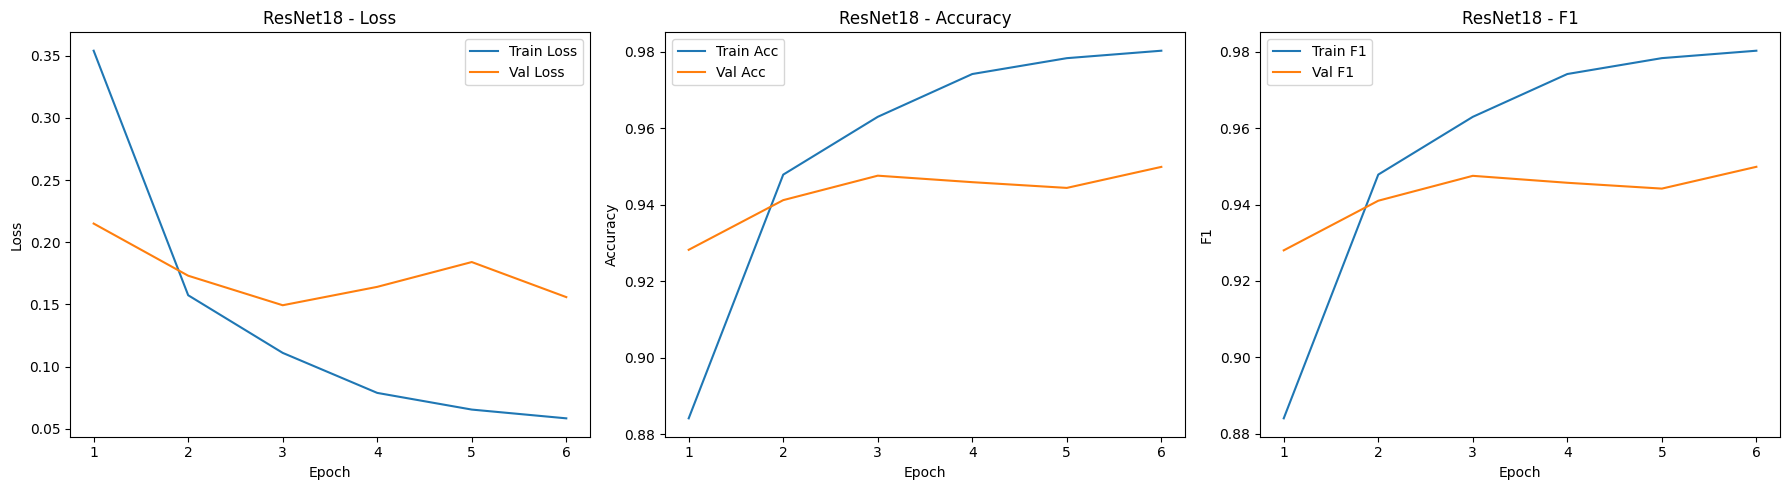

ResNet18 | test_f1=0.9472 | test_precision=0.9475 | test_recall=0.9472 | test_acc=0.9472


In [14]:
print("ResNet18: training")
resnet18 = build_resnet18(num_classes=NUM_CLASSES)
resnet18, hist = fit_model(
    resnet18,
    train_loader_224,
    val_loader_224,
    epochs=6,
    lr=1e-4
)
plot_training_history(hist, title="ResNet18")

_, val_acc, val_f1, val_precision, val_recall, _, _, _ = test_model(resnet18, val_loader_224)
_, test_acc, test_f1, test_precision, test_recall, y_true, y_pred, cm = test_model(resnet18, test_loader_224)

deep_results["ResNet18"] = {
    "model_type": "Modern CNN",
    "val_acc": val_acc,
    "test_acc": test_acc,
    "val_precision": val_precision,
    "val_recall": val_recall,
    "val_f1": val_f1,
    "test_precision": test_precision,
    "test_recall": test_recall,
    "test_f1": test_f1
}
deep_histories["ResNet18"] = hist
deep_conf_mats["ResNet18"] = cm
print(
    f"ResNet18 | test_f1={test_f1:.4f} | test_precision={test_precision:.4f} "
    f"| test_recall={test_recall:.4f} | test_acc={test_acc:.4f}"
)


EfficientNet-B0: training
Epoch 01/6 - train: loss=0.4890, acc=0.8545, f1=0.8542 | val: loss=0.1493, acc=0.9525, f1=0.9525
Epoch 02/6 - train: loss=0.1609, acc=0.9460, f1=0.9459 | val: loss=0.1218, acc=0.9584, f1=0.9583
Epoch 03/6 - train: loss=0.1109, acc=0.9633, f1=0.9633 | val: loss=0.1098, acc=0.9632, f1=0.9632
Epoch 04/6 - train: loss=0.0772, acc=0.9742, f1=0.9742 | val: loss=0.1061, acc=0.9647, f1=0.9647
Epoch 05/6 - train: loss=0.0614, acc=0.9791, f1=0.9791 | val: loss=0.1105, acc=0.9640, f1=0.9640
Epoch 06/6 - train: loss=0.0498, acc=0.9838, f1=0.9837 | val: loss=0.1048, acc=0.9667, f1=0.9667


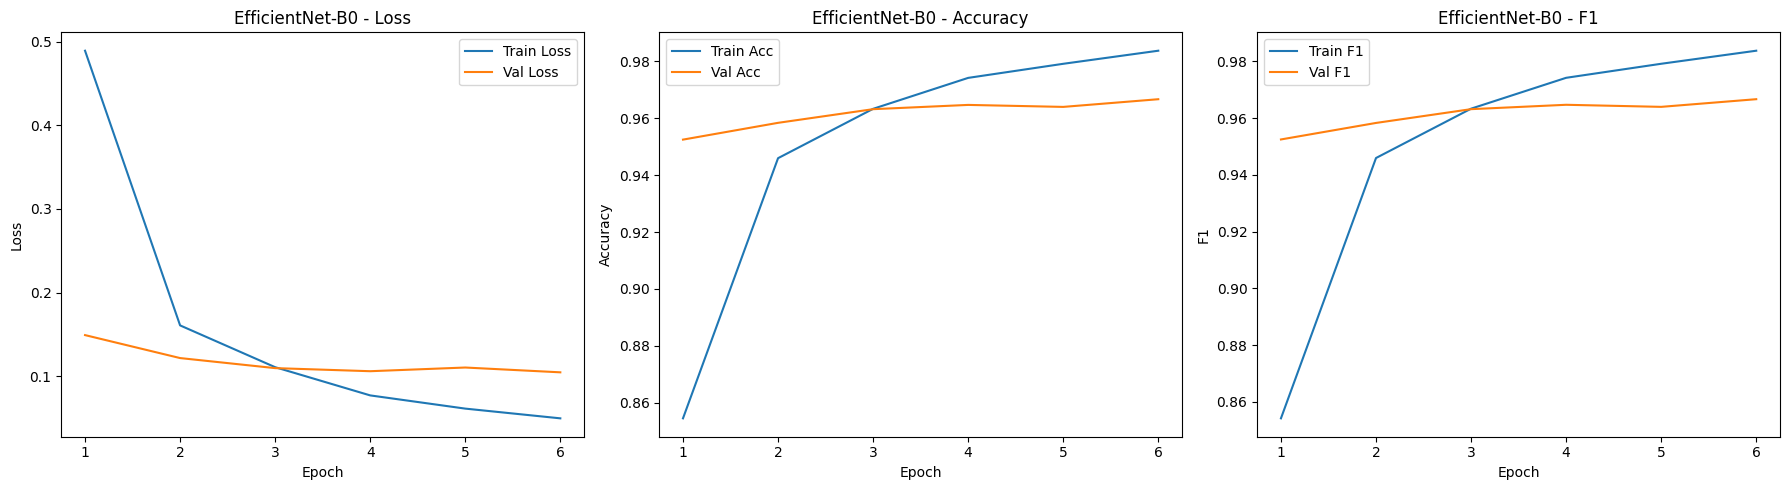

EfficientNet-B0 | test_f1=0.9679 | test_precision=0.9679 | test_recall=0.9679 | test_acc=0.9679


In [15]:
print("EfficientNet-B0: training")
efficientnet = build_efficientnet_b0(num_classes=NUM_CLASSES)
efficientnet, hist = fit_model(
    efficientnet,
    train_loader_224,
    val_loader_224,
    epochs=6,
    lr=1e-4
)
plot_training_history(hist, title="EfficientNet-B0")

_, val_acc, val_f1, val_precision, val_recall, _, _, _ = test_model(efficientnet, val_loader_224)
_, test_acc, test_f1, test_precision, test_recall, y_true, y_pred, cm = test_model(efficientnet, test_loader_224)

deep_results["EfficientNet-B0"] = {
    "model_type": "Modern CNN",
    "val_acc": val_acc,
    "test_acc": test_acc,
    "val_precision": val_precision,
    "val_recall": val_recall,
    "val_f1": val_f1,
    "test_precision": test_precision,
    "test_recall": test_recall,
    "test_f1": test_f1
}
deep_histories["EfficientNet-B0"] = hist
deep_conf_mats["EfficientNet-B0"] = cm
print(
    f"EfficientNet-B0 | test_f1={test_f1:.4f} | test_precision={test_precision:.4f} "
    f"| test_recall={test_recall:.4f} | test_acc={test_acc:.4f}"
)


In [16]:
USE_VIT = False

if USE_VIT:
    print("ViT-B/16: training")
    vit = build_vit_b_16(num_classes=NUM_CLASSES)
    vit, hist = fit_model(
        vit,
        train_loader_224,
        val_loader_224,
        epochs=5,
        lr=1e-4
    )
    plot_training_history(hist, title="ViT-B/16")

    _, val_acc, val_f1, val_precision, val_recall, _, _, _ = test_model(vit, val_loader_224)
    _, test_acc, test_f1, test_precision, test_recall, y_true, y_pred, cm = test_model(vit, test_loader_224)

    deep_results["ViT-B/16"] = {
        "model_type": "Transformer Vision Model",
        "val_acc": val_acc,
        "test_acc": test_acc,
        "val_precision": val_precision,
        "val_recall": val_recall,
        "val_f1": val_f1,
        "test_precision": test_precision,
        "test_recall": test_recall,
        "test_f1": test_f1
    }
    deep_histories["ViT-B/16"] = hist
    deep_conf_mats["ViT-B/16"] = cm
    print(
        f"ViT-B/16 | test_f1={test_f1:.4f} | test_precision={test_precision:.4f} "
        f"| test_recall={test_recall:.4f} | test_acc={test_acc:.4f}"
    )


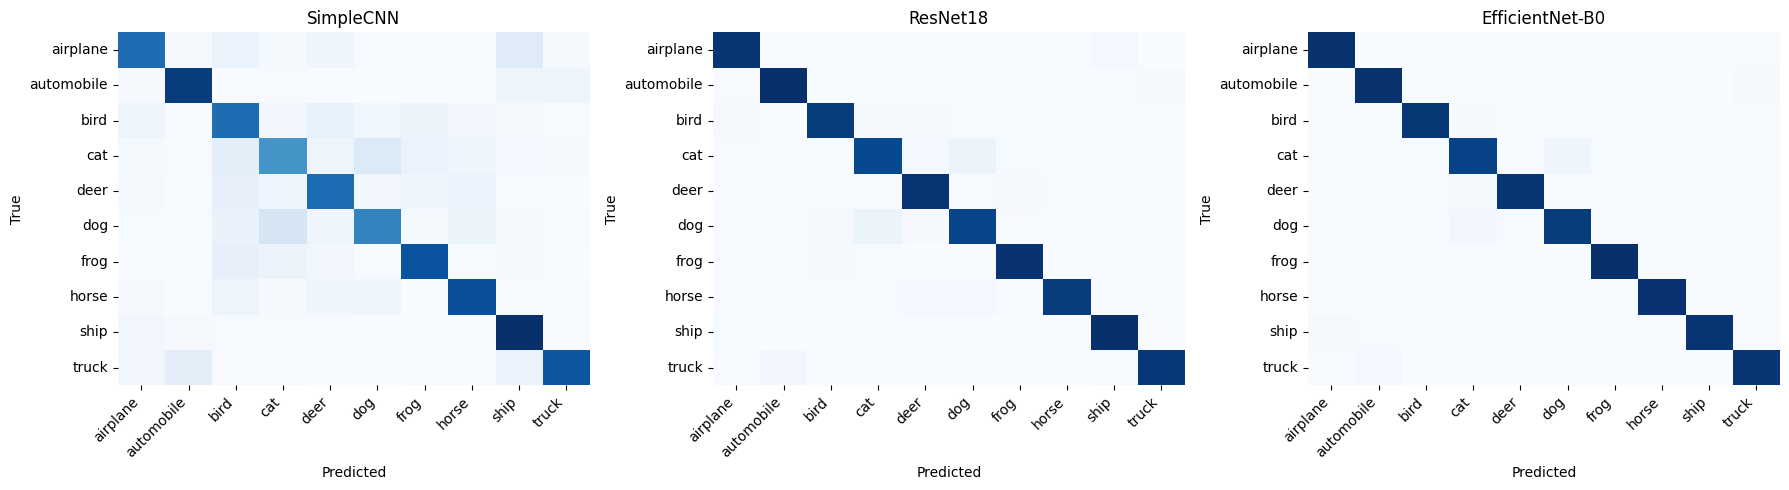

In [17]:
n_models = len(deep_conf_mats)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))

if n_models == 1:
    axes = [axes]

for ax, (name, cm) in zip(axes, deep_conf_mats.items()):
    sns.heatmap(cm, annot=False, cmap="Blues", cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(np.arange(NUM_CLASSES) + 0.5)
    ax.set_yticks(np.arange(NUM_CLASSES) + 0.5)
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_NAMES, rotation=0)

plt.tight_layout()
plt.show()

## Part 5 - Model Comparison
Compare all models with F1 as the primary ranking metric.


In [18]:
all_results = {}
all_results.update(classical_results)
all_results.update(deep_results)

results_df = pd.DataFrame(all_results).T
results_df = results_df.sort_values(["test_f1", "test_acc"], ascending=False)
results_df


,model_type,val_acc,test_acc,val_precision,val_recall,val_f1,test_precision,test_recall,test_f1,train_time_sec
EfficientNet-B0,Modern CNN,0.9667,0.9679,0.966742,0.9667,0.966664,0.967905,0.9679,0.967867,NaN
ResNet18,Modern CNN,0.9499,0.9472,0.950293,0.9499,0.949885,0.947517,0.9472,0.947174,NaN
SimpleCNN,Deep Learning,0.7545,0.754,0.757235,0.7545,0.753653,0.756464,0.754,0.752973,NaN
RandomForest,Classical ML,0.451,0.4398,0.44358,0.451,0.445001,0.430387,0.4398,0.43172,5.440482
LogisticRegression,Classical ML,0.4025,0.3986,0.398158,0.4025,0.399316,0.393641,0.3986,0.395064,5.902858
LinearSVM,Classical ML,0.398,0.3942,0.390352,0.398,0.387091,0.381098,0.3942,0.380811,6.888818
KNN,Classical ML,0.33625,0.3402,0.402686,0.33625,0.328929,0.400134,0.3402,0.328528,2.577052


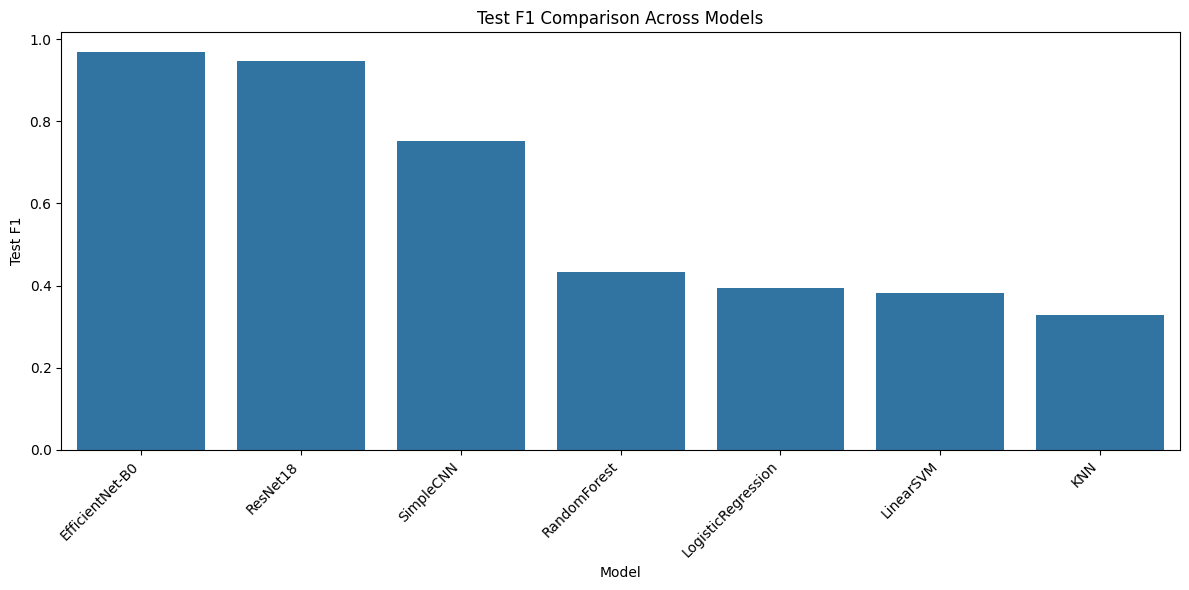

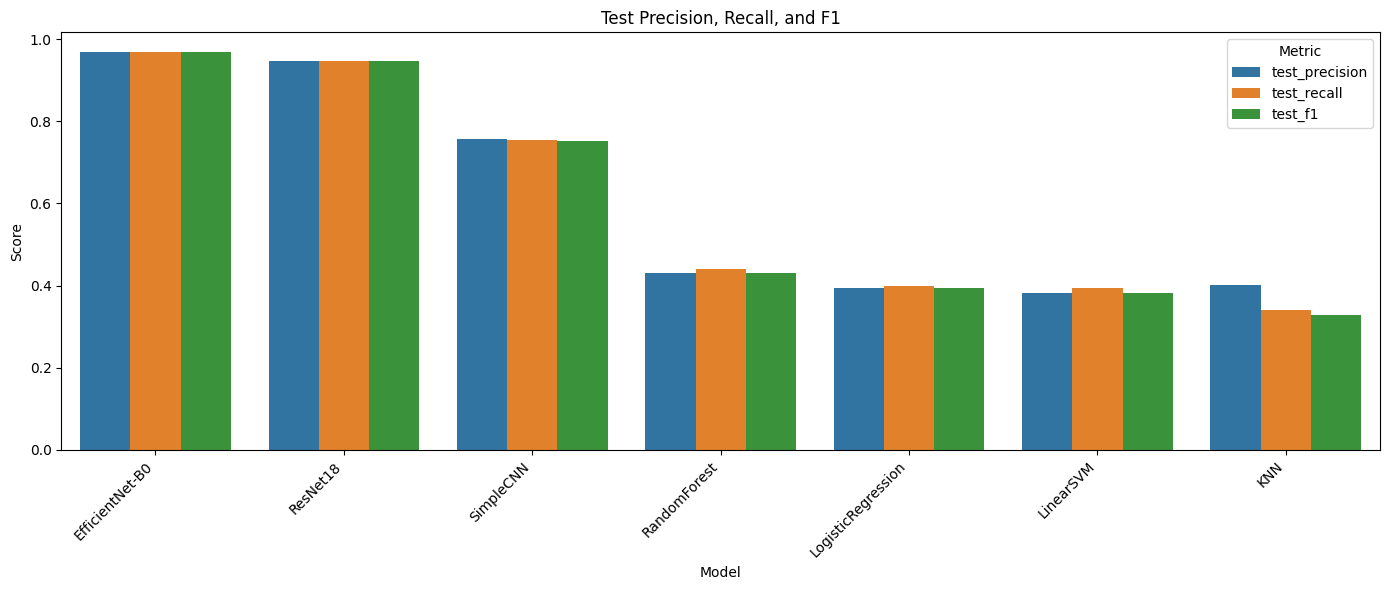

In [19]:
metrics_for_plot = results_df.reset_index().rename(columns={"index": "model"})

plt.figure(figsize=(12, 6))
sns.barplot(data=metrics_for_plot, x="model", y="test_f1")
plt.xticks(rotation=45, ha="right")
plt.title("Test F1 Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("Test F1")
plt.tight_layout()
plt.show()

plot_df = metrics_for_plot[["model", "test_precision", "test_recall", "test_f1"]].melt(
    id_vars="model",
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(14, 6))
sns.barplot(data=plot_df, x="model", y="value", hue="metric")
plt.xticks(rotation=45, ha="right")
plt.title("Test Precision, Recall, and F1")
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


## Part 6 - Best Model Report
Show detailed classification metrics for the best model by test F1.


In [20]:
best_model_name = results_df.index[0]
print(f"Best model by test F1: {best_model_name}")

if best_model_name in classical_predictions:
    y_pred_best = classical_predictions[best_model_name]
    print(classification_report(y_test_small, y_pred_best, target_names=CLASS_NAMES))
else:
    model_map = {
        "SimpleCNN": simple_cnn,
        "ResNet18": resnet18,
        "EfficientNet-B0": efficientnet
    }
    if USE_VIT:
        model_map["ViT-B/16"] = vit

    best_model = model_map[best_model_name]

    if best_model_name == "SimpleCNN":
        _, _, _, _, _, y_true, y_pred, _ = test_model(best_model, test_loader_32)
    else:
        _, _, _, _, _, y_true, y_pred, _ = test_model(best_model, test_loader_224)

    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


Best model by test F1: EfficientNet-B0
              precision    recall  f1-score   support

    airplane       0.97      0.98      0.98      1000
  automobile       0.97      0.98      0.98      1000
        bird       0.97      0.96      0.97      1000
         cat       0.93      0.92      0.93      1000
        deer       0.97      0.97      0.97      1000
         dog       0.94      0.94      0.94      1000
        frog       0.98      0.99      0.99      1000
       horse       0.98      0.98      0.98      1000
        ship       0.99      0.98      0.98      1000
       truck       0.98      0.97      0.97      1000

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



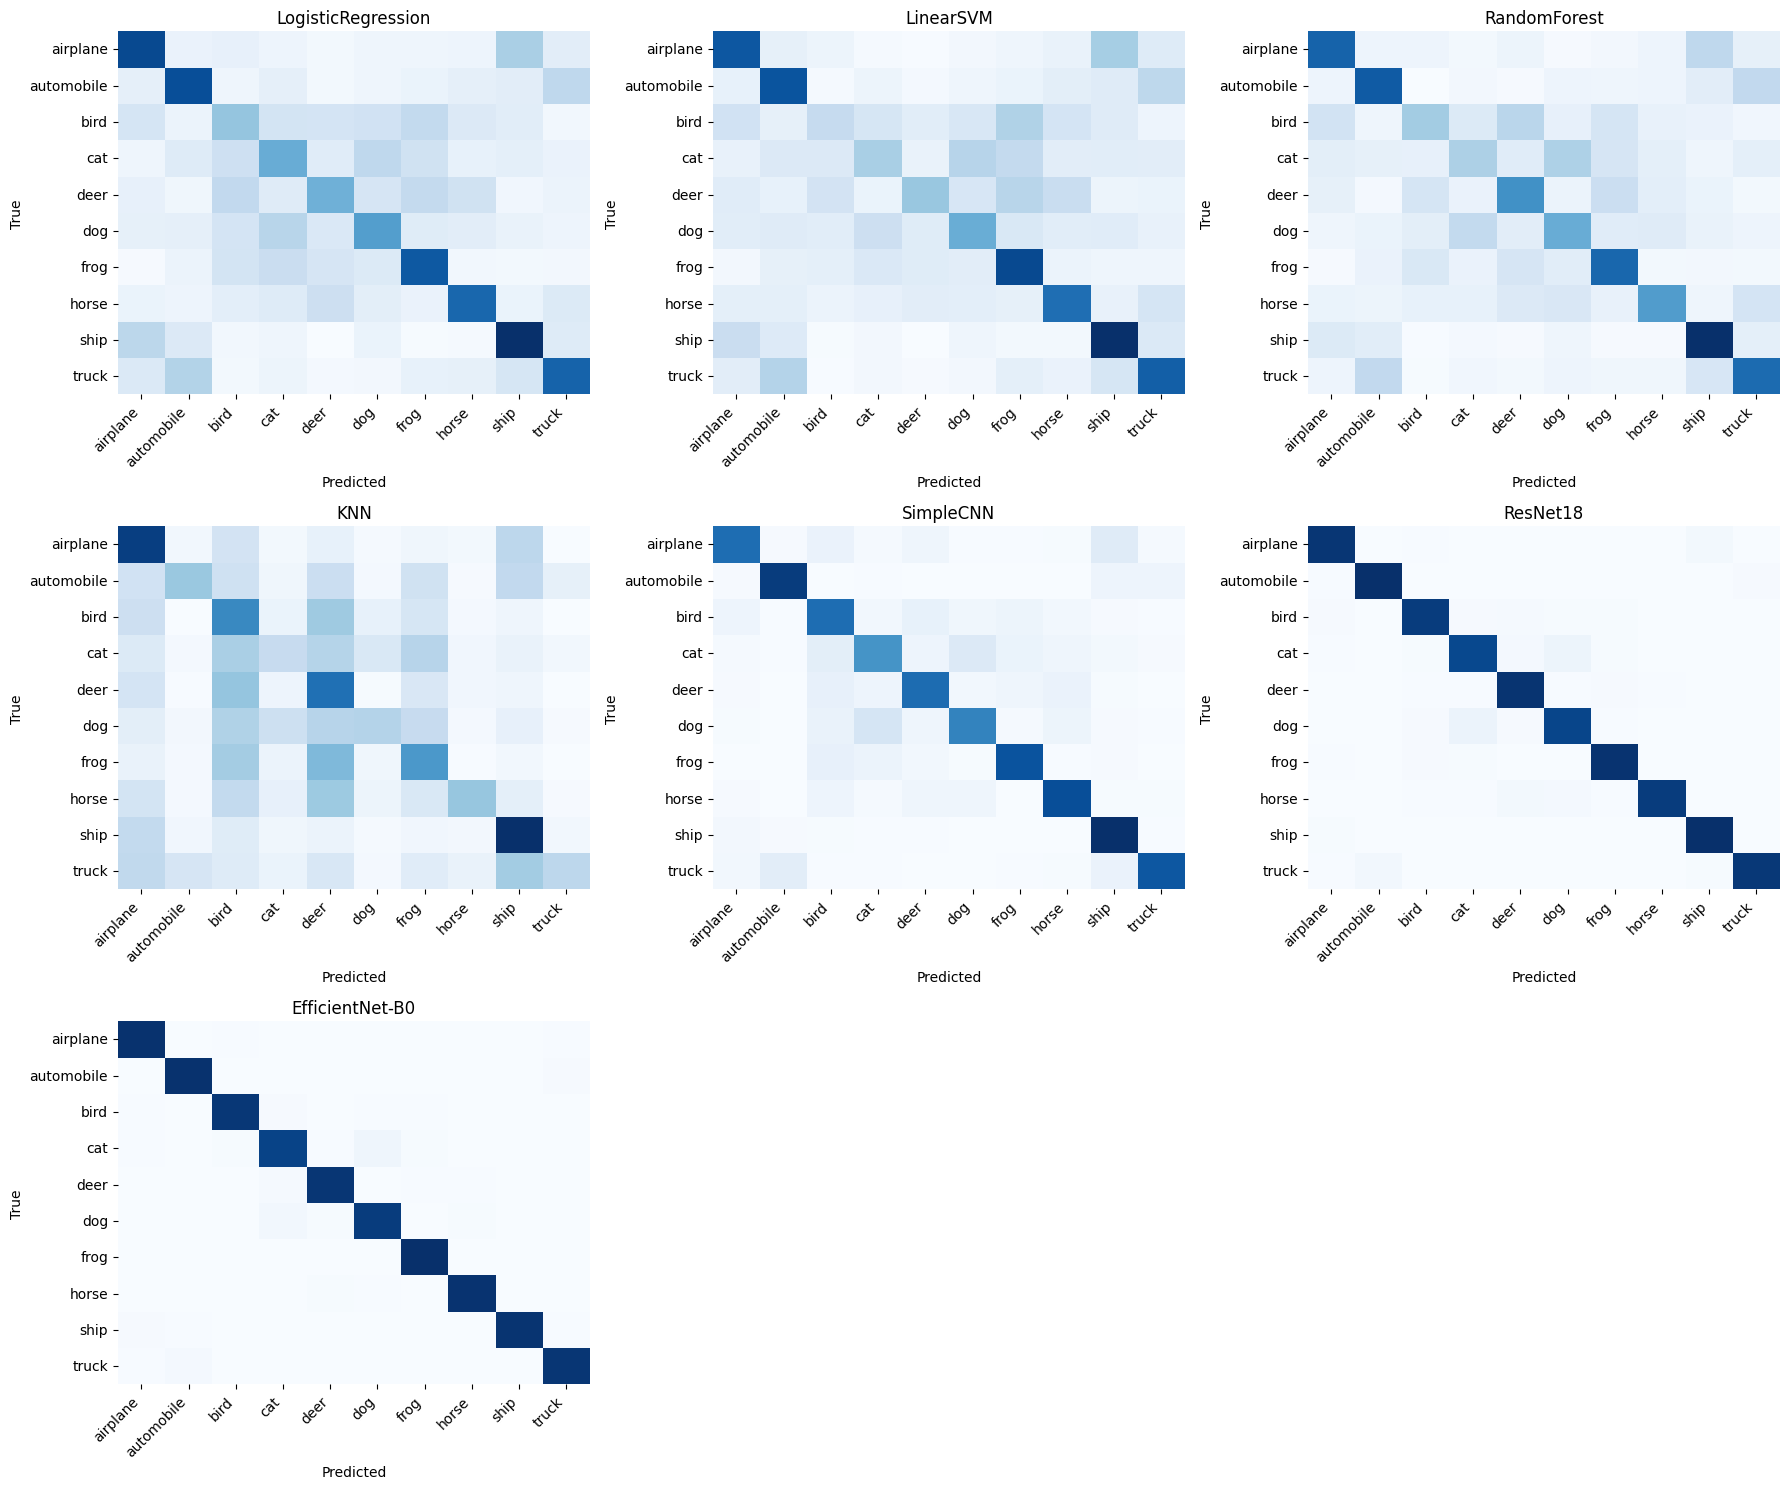

In [21]:
all_conf_mats = {}
all_conf_mats.update(classical_conf_mats)
all_conf_mats.update(deep_conf_mats)

n = len(all_conf_mats)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = np.array(axes).reshape(-1)

for ax, (name, cm) in zip(axes, all_conf_mats.items()):
    sns.heatmap(cm, annot=False, cmap="Blues", cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(np.arange(NUM_CLASSES) + 0.5)
    ax.set_yticks(np.arange(NUM_CLASSES) + 0.5)
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_NAMES, rotation=0)

for i in range(len(all_conf_mats), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### Note: No real reason for validation and test split as there is no tuning.